## **Imports**

In [ ]:
import os
import glob
import json
import joblib
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from torchvision import datasets, transforms

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset


In [2]:
# Verify GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Dataset Loading**

In [8]:
# Auto-detect MaleVis dataset directory inside /kaggle/input/
malevis_dir = "/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300"

## **Preprocessing and Data Loaders**

In [9]:
# Image dimensions and normalization constants
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

In [10]:
# Define PyTorch Transformations (Preprocessing Pipeline)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD)
    ]),
    'inference': transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD)
    ])
}

# Lightweight Dataset that loads directly from a fixed (path, label) sample list.
# This lets us apply a different transform per split (train/val/test) after a
# single stratified split, instead of being locked into whatever folder layout
# the raw dataset ships with.
class MaleVisSamples(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [11]:
# Gather the full (path, label) sample list regardless of whether the dataset
# ships as a single folder or a pre-split train/val folder pair
train_path = os.path.join(malevis_dir, 'train') if os.path.exists(os.path.join(malevis_dir, 'train')) else malevis_dir
prevalsplit_path = os.path.join(malevis_dir, 'val') if os.path.exists(os.path.join(malevis_dir, 'val')) else None

if prevalsplit_path and os.path.exists(prevalsplit_path):
    part_a = datasets.ImageFolder(root=train_path)
    part_b = datasets.ImageFolder(root=prevalsplit_path)
    assert part_a.class_to_idx == part_b.class_to_idx, "Class mapping mismatch between pre-split folders"
    all_samples = part_a.samples + part_b.samples
    class_to_idx = part_a.class_to_idx
else:
    full_folder = datasets.ImageFolder(root=malevis_dir)
    all_samples = full_folder.samples
    class_to_idx = full_folder.class_to_idx

idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
all_labels = [label for _, label in all_samples]

In [12]:
# Create a 70% Train, 15% Validation, and 15% Test Split (stratified, mirrors the XGBoost notebook)
train_samples, temp_samples, train_labels, temp_labels = train_test_split(
    all_samples, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
val_samples, test_samples, val_labels, test_labels = train_test_split(
    temp_samples, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

train_dataset = MaleVisSamples(train_samples, transform=data_transforms['train'])
val_dataset   = MaleVisSamples(val_samples,   transform=data_transforms['inference'])
test_dataset  = MaleVisSamples(test_samples,  transform=data_transforms['inference'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("=== Split Summary ===")
print(f"Train set size:      {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size:       {len(test_dataset)}")

=== Split Summary ===
Train set size:      9958
Validation set size: 2134
Test set size:       2134


In [13]:
# Class names and label mapping (derived during the split above)
label_mapping = {idx: name for idx, name in enumerate(class_names)}
print(f"Detected {len(class_names)} classes: {class_names}")


Detected 26 classes: ['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Other', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']


In [14]:
# Save Preprocessing Config & Class Mapping for Inference
pipeline_config = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "norm_mean": NORM_MEAN,
    "norm_std": NORM_STD,
    "classes": class_names,
    "label_mapping": label_mapping
}

pipeline_path = "/kaggle/working/cnn_preprocessing_pipeline.json"
with open(pipeline_path, "w") as f:
    json.dump(pipeline_config, f, indent=4)

print(f"Preprocessing configuration saved to: {pipeline_path}")


Preprocessing configuration saved to: /kaggle/working/cnn_preprocessing_pipeline.json


## **Model**

In [15]:
class MaleVisCNN(nn.Module):
    def __init__(self, num_classes):
        super(MaleVisCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x32 -> 16x16
            
            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
num_classes = len(class_names)
model = MaleVisCNN(num_classes=num_classes).to(device)
print(model)

MaleVisCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

## **Training**

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

In [18]:
print("Starting CNN Model Training...\n")

for epoch in range(epochs):
    # --- Train ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    # --- Validate ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] - "
          f"Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc*100:.2f}% - "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")


Starting CNN Model Training...

Epoch [1/15] - Train Loss: 1.6792 - Train Acc: 58.73% - Val Loss: 0.7176 - Val Acc: 80.88%
Epoch [2/15] - Train Loss: 0.8827 - Train Acc: 75.34% - Val Loss: 0.6696 - Val Acc: 81.77%
Epoch [3/15] - Train Loss: 0.6901 - Train Acc: 80.39% - Val Loss: 0.3940 - Val Acc: 89.27%
Epoch [4/15] - Train Loss: 0.6122 - Train Acc: 82.50% - Val Loss: 0.3658 - Val Acc: 89.64%
Epoch [5/15] - Train Loss: 0.5446 - Train Acc: 83.90% - Val Loss: 0.3488 - Val Acc: 90.16%
Epoch [6/15] - Train Loss: 0.4973 - Train Acc: 85.53% - Val Loss: 0.3317 - Val Acc: 89.88%
Epoch [7/15] - Train Loss: 0.4435 - Train Acc: 87.07% - Val Loss: 0.3024 - Val Acc: 91.99%
Epoch [8/15] - Train Loss: 0.3987 - Train Acc: 88.00% - Val Loss: 0.2964 - Val Acc: 92.08%
Epoch [9/15] - Train Loss: 0.3604 - Train Acc: 89.24% - Val Loss: 0.2391 - Val Acc: 93.11%
Epoch [10/15] - Train Loss: 0.3212 - Train Acc: 90.23% - Val Loss: 0.2684 - Val Acc: 92.55%
Epoch [11/15] - Train Loss: 0.3149 - Train Acc: 90.24% - 

In [19]:
# Save Trained Model File
model_pth_path = "/kaggle/working/malevis_cnn_model.pth"
torch.save(model.state_dict(), model_pth_path)
print(f"\nTrained CNN model weights saved to: {model_pth_path}")


Trained CNN model weights saved to: /kaggle/working/malevis_cnn_model.pth


## **Evaluation**

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate Metrics
acc = accuracy_score(all_labels, all_preds)
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
class_report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
class_report_str = classification_report(all_labels, all_preds, target_names=class_names)

print("=== Evaluation Results ===")
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Weighted F1-Score: {f1_weighted:.4f}\n")
print("Classification Report:\n", class_report_str)

=== Evaluation Results ===
Test Accuracy: 94.38%
Weighted F1-Score: 0.9435

Classification Report:
               precision    recall  f1-score   support

    Adposhel       1.00      1.00      1.00        74
       Agent       0.92      0.83      0.87        70
     Allaple       0.97      0.96      0.96        71
   Amonetize       1.00      0.97      0.99        75
      Androm       0.89      0.89      0.89        75
     Autorun       0.97      0.88      0.92        75
   BrowseFox       0.92      0.97      0.95        74
      Dinwod       0.96      0.99      0.97        75
        Elex       0.99      0.93      0.96        75
      Expiro       0.86      0.93      0.90        75
      Fasong       1.00      1.00      1.00        75
     HackKMS       1.00      1.00      1.00        75
        Hlux       1.00      1.00      1.00        75
    Injector       0.92      0.77      0.84        74
 InstallCore       1.00      1.00      1.00        75
   MultiPlug       0.97      0.93  

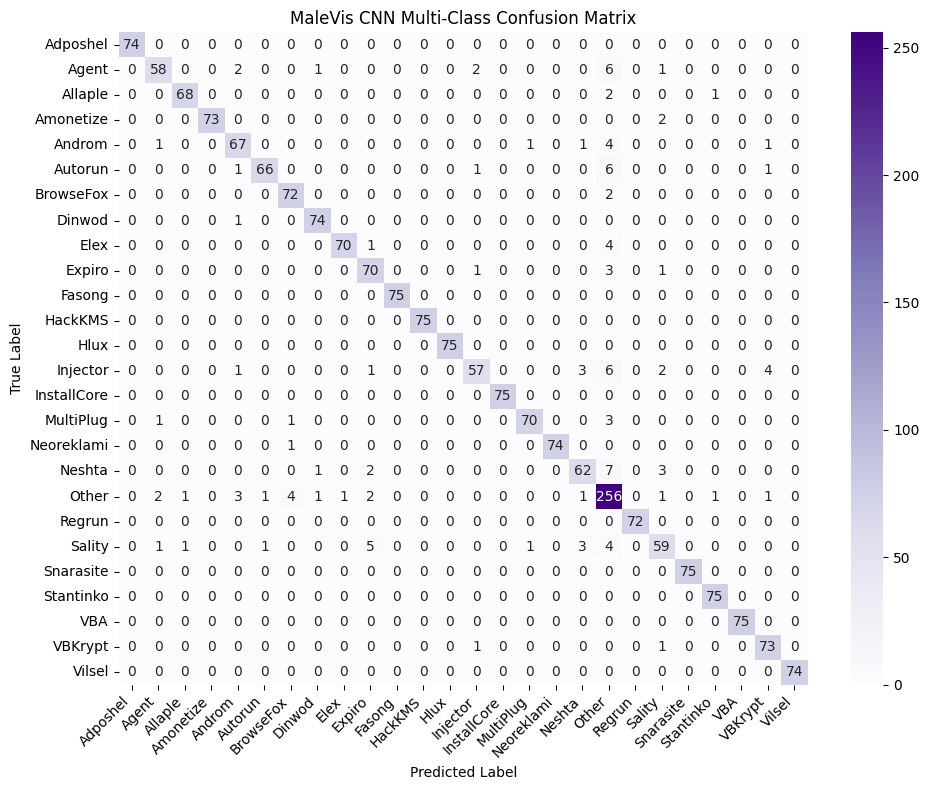

In [21]:
# Generate Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MaleVis CNN Multi-Class Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Save performance metrics to JSON
metrics = {
    "accuracy": acc,
    "f1_score_weighted": f1_weighted,
    "classification_report": class_report_dict
}

metrics_json_path = "/kaggle/working/cnn_performance_metrics.json"
with open(metrics_json_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print("\n=== Saved Output Files in /kaggle/working/ ===")
for file_name in os.listdir("/kaggle/working/"):
    print(f" - /kaggle/working/{file_name}")


=== Saved Output Files in /kaggle/working/ ===
 - /kaggle/working/.virtual_documents
 - /kaggle/working/cnn_preprocessing_pipeline.json
 - /kaggle/working/cnn_performance_metrics.json
 - /kaggle/working/malevis_cnn_model.pth


## **Caliberation with Platt Scaling**

In [23]:
print("=== Performing Probability Calibration (Platt Scaling) ===")

def get_logits_and_labels(model, loader, device):
    """Runs the trained CNN and collects raw (pre-softmax) logits + true labels."""
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_logits.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)

# Collect raw logits on the Validation set (used to FIT calibration) and Test set (used to EVAL it)
val_logits, val_labels_arr = get_logits_and_labels(model, val_loader, device)
test_logits, test_labels_arr = get_logits_and_labels(model, test_loader, device)

num_classes = len(class_names)

# Fit one-vs-rest Platt (sigmoid) calibrators - one per class - on Validation logits.
# This mirrors sklearn's CalibratedClassifierCV(method='sigmoid', cv='prefit') used in the
# XGBoost notebook: for each class we fit sigmoid(A * logit_c + B) against the binary
# "is this class" target using only the held-out validation set.
platt_calibrators = []
for c in range(num_classes):
    binary_targets = (val_labels_arr == c).astype(int)
    calibrator = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
    calibrator.fit(val_logits[:, c].reshape(-1, 1), binary_targets)
    platt_calibrators.append(calibrator)

def apply_platt_scaling(logits, calibrators):
    """Applies fitted per-class Platt calibrators and renormalizes into a valid distribution."""
    n_samples = logits.shape[0]
    n_classes = len(calibrators)
    calibrated = np.zeros((n_samples, n_classes))
    for c, calibrator in enumerate(calibrators):
        calibrated[:, c] = calibrator.predict_proba(logits[:, c].reshape(-1, 1))[:, 1]
    row_sums = calibrated.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-12
    return calibrated / row_sums

# Evaluate calibrated probabilities on the Test Set
calibrated_probs = apply_platt_scaling(test_logits, platt_calibrators)
calibrated_preds = np.argmax(calibrated_probs, axis=1)

cal_acc = accuracy_score(test_labels_arr, calibrated_preds)
calibrated_f1_weighted = f1_score(test_labels_arr, calibrated_preds, average='weighted')
calibrated_f1_per_class = f1_score(test_labels_arr, calibrated_preds, average=None)

print(f"Calibrated Test Accuracy: {cal_acc * 100:.2f}%")
print(f"Calibrated Weighted F1-Score: {calibrated_f1_weighted:.4f}")
print(f"Calibrated Per class F1-Score: {calibrated_f1_per_class}")

# Save Calibration Artifacts
calibration_path = "/kaggle/working/cnn_platt_calibrators.joblib"
joblib.dump(platt_calibrators, calibration_path)
print(f"Calibrated model (Platt calibrators) saved to: {calibration_path}")


=== Performing Probability Calibration (Platt Scaling) ===
Calibrated Test Accuracy: 91.80%
Calibrated Weighted F1-Score: 0.9188
Calibrated Per class F1-Score: [1.         0.87218045 0.96453901 0.98648649 0.90540541 0.90780142
 0.96       0.97368421 0.95890411 0.81142857 1.         0.99337748
 1.         0.79699248 0.99337748 0.95172414 0.98039216 0.7
 0.8030303  0.99310345 0.72580645 0.98684211 0.98039216 1.
 0.95424837 1.        ]
Calibrated model (Platt calibrators) saved to: /kaggle/working/cnn_platt_calibrators.joblib


In [24]:
print("=== Platt Scaling Parameters (Sigmoid Weights & Biases) ===")

for idx, class_name in enumerate(class_names):
    a_param = platt_calibrators[idx].coef_[0][0]
    b_param = platt_calibrators[idx].intercept_[0]
    print(f"Class: {class_name:15s} | Weight (A): {a_param:10.5f} | Bias (B): {b_param:10.5f}")


=== Platt Scaling Parameters (Sigmoid Weights & Biases) ===
Class: Adposhel        | Weight (A):    0.87957 | Bias (B):   -7.69027
Class: Agent           | Weight (A):    1.03981 | Bias (B):   -7.66361
Class: Allaple         | Weight (A):    1.03207 | Bias (B):   -7.21393
Class: Amonetize       | Weight (A):    0.69740 | Bias (B):   -6.73883
Class: Androm          | Weight (A):    0.68060 | Bias (B):   -6.21057
Class: Autorun         | Weight (A):    0.82516 | Bias (B):   -7.33660
Class: BrowseFox       | Weight (A):    0.90191 | Bias (B):   -6.93975
Class: Dinwod          | Weight (A):    1.76422 | Bias (B):  -10.80490
Class: Elex            | Weight (A):    0.46189 | Bias (B):   -4.47928
Class: Expiro          | Weight (A):    0.72731 | Bias (B):   -5.20997
Class: Fasong          | Weight (A):    1.01101 | Bias (B):   -9.09202
Class: HackKMS         | Weight (A):    2.64124 | Bias (B):   -5.95609
Class: Hlux            | Weight (A):    0.76481 | Bias (B):   -6.05494
Class: Injector  

## **Precompute Class Weights w(c)**

In [ ]:
print("=== Precomputing Class Weights w(c) = precision(c) * log(1 + 1/baserate(c)) ===")

# Precision per class, computed on the CALIBRATED test-set predictions (not the raw softmax
# predictions) so these weights stay consistent with the calibrated probabilities that will
# actually be used downstream at inference time.
calibrated_class_report = classification_report(
    test_labels_arr, calibrated_preds, target_names=class_names, output_dict=True
)
precision_dict = {c: calibrated_class_report[c]['precision'] for c in class_names}

# Base rate = class frequency in the TRAINING distribution (the prior the model actually
# learned from), computed from train_labels produced during the 70/15/15 split.
train_label_counts = Counter(train_labels)
total_train = len(train_labels)
baserate_dict = {
    class_names[idx]: train_label_counts.get(idx, 0) / total_train
    for idx in range(len(class_names))
}

epsilon = 1e-6
raw_weight_dict = {}
for c in class_names:
    base = max(baserate_dict[c], epsilon)
    raw_weight_dict[c] = precision_dict[c] * np.log(1 + 1 / base)

# Normalize by max (not sum) so the aggregate raw_score used later can still grow/shrink
# with genuine evidence strength, rather than being forced onto a fixed budget.
max_w = max(raw_weight_dict.values()) if raw_weight_dict else 1.0
w_normalized_dict = {
    c: (v / max_w if max_w > 0 else 0.0) for c, v in raw_weight_dict.items()
}

class_weights_output = {
    "precision": precision_dict,
    "baserate": baserate_dict,
    "raw_weight": raw_weight_dict,
    "w_normalized": w_normalized_dict
}

class_weights_path = "/kaggle/working/cnn_class_weights.json"
with open(class_weights_path, "w") as f:
    json.dump(class_weights_output, f, indent=4)

print(f"Class weights saved to: {class_weights_path}\n")
print(f"{'Class':15s} | {'Precision':>9s} | {'BaseRate':>9s} | {'RawWeight':>10s} | {'w_norm':>7s}")
for c in class_names:
    print(f"{c:15s} | {precision_dict[c]:9.4f} | {baserate_dict[c]:9.4f} | "
          f"{raw_weight_dict[c]:10.4f} | {w_normalized_dict[c]:7.4f}")


## **Inference**

In [ ]:
def cnn_calibrated_inference(input_data, model_path, pipeline_path, calibration_path,
                              model_class=MaleVisCNN, device=device, sample_lookup=None):
    """
    Performs standalone inference on new image sample(s) using the Platt Scaled CNN model.

    input_data: any of the following, or a list mixing them:
      - a file path (str / os.PathLike)
      - a PIL.Image
      - an int index into `sample_lookup` (e.g. id=4) -- requires sample_lookup to be passed.
        This lets you manually pick a specific dataset sample (e.g. from test_samples) by
        index without pre-extracting paths yourself.
    sample_lookup: a list of (path, label) tuples, e.g. `test_samples`, used to resolve
        integer indices in input_data. Only required if you pass int indices.
    """
    # 1. Load preprocessing config
    with open(pipeline_path, "r") as f:
        pipeline_config = json.load(f)

    img_size = tuple(pipeline_config["img_size"])
    norm_mean = pipeline_config["norm_mean"]
    norm_std = pipeline_config["norm_std"]
    classes = pipeline_config["classes"]

    inference_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ])

    # 2. Load model architecture (unchanged) and trained weights
    inf_model = model_class(num_classes=len(classes)).to(device)
    inf_model.load_state_dict(torch.load(model_path, map_location=device))
    inf_model.eval()

    # 3. Load fitted Platt scaling calibrators
    calibrators = joblib.load(calibration_path)

    # 4. Normalize input into a list of (PIL.Image, ground_truth_label_or_None)
    def resolve(item):
        if isinstance(item, (str, os.PathLike)):
            return Image.open(item).convert('RGB'), None
        elif isinstance(item, Image.Image):
            return item.convert('RGB'), None
        elif isinstance(item, (int, np.integer)):
            if sample_lookup is None:
                raise ValueError(
                    "Got an integer index but no sample_lookup was provided. "
                    "Pass sample_lookup=test_samples (or similar) to resolve indices."
                )
            path, label = sample_lookup[item]
            return Image.open(path).convert('RGB'), label
        else:
            raise ValueError("input_data items must be a file path, PIL Image, or int index.")

    if isinstance(input_data, list):
        resolved = [resolve(item) for item in input_data]
    else:
        resolved = [resolve(input_data)]

    images = [r[0] for r in resolved]
    ground_truth_ids = [r[1] for r in resolved]

    # 5. Preprocess and batch
    batch = torch.stack([inference_transform(img) for img in images]).to(device)

    # 6. Forward pass to get raw logits
    with torch.no_grad():
        logits = inf_model(batch).cpu().numpy()

    # 7. Apply Platt scaling calibration (same logic as apply_platt_scaling above)
    n_samples = logits.shape[0]
    n_classes = len(classes)
    calibrated = np.zeros((n_samples, n_classes))
    for c, calibrator in enumerate(calibrators):
        calibrated[:, c] = calibrator.predict_proba(logits[:, c].reshape(-1, 1))[:, 1]
    row_sums = calibrated.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-12
    calibrated_probs_out = calibrated / row_sums

    predictions = np.argmax(calibrated_probs_out, axis=1)
    predicted_classes = [classes[p] for p in predictions]

    # 8. Build results in dictionary form
    results = {
        "Predicted_Class_ID": predictions,
        "Predicted_Class": predicted_classes,
        "Calibrated_Confidence": np.max(calibrated_probs_out, axis=1),
        "Probability_Distribution": calibrated_probs_out,
        "Ground_Truth_ID": ground_truth_ids,
        "Ground_Truth_Class": [classes[g] if g is not None else None for g in ground_truth_ids]
    }

    return results


## **Run**

In [ ]:
# --- MANUAL INFERENCE RUN ---
# Set any dataset index/indices here to manually inspect specific test samples,
# e.g. a single id: manual_ids = 4, or a handful: manual_ids = [4, 17, 42].
# These indices refer to positions in `test_samples` (the held-out test split).
manual_ids = [4, 17, 42]

print("=== Running Custom Inference Pipeline (Calibrated CNN Model) ===")
inference_results = cnn_calibrated_inference(
    input_data=manual_ids,
    model_path="/kaggle/working/malevis_cnn_model.pth",
    pipeline_path="/kaggle/working/cnn_preprocessing_pipeline.json",
    calibration_path="/kaggle/working/cnn_platt_calibrators.joblib",
    sample_lookup=test_samples
)

print("\nInference Results for Selected Samples:")
for i, sample_id in enumerate(manual_ids):
    print(f"\n--- Sample id={sample_id} ---")
    print(f"Ground Truth:          {inference_results['Ground_Truth_Class'][i]}")
    print(f"Predicted Class:       {inference_results['Predicted_Class'][i]}")
    print(f"Calibrated Confidence: {inference_results['Calibrated_Confidence'][i]:.4f}")


In [ ]:
# Full calibrated probability distribution for the first selected sample
idx0 = 0
print(f"Full calibrated probability distribution for sample id={manual_ids[idx0]}:")
for cname, p in zip(class_names, inference_results['Probability_Distribution'][idx0]):
    print(f"  {cname:15s}: {p:.4f}")
